In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

In [2]:
# using linear regression 
#checking the data 
df=pd.read_csv("Student_Performance.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=10000, step=1)
All columns are
0 Hours Studied
1 Previous Scores
2 Extracurricular Activities
3 Sleep Hours
4 Sample Question Papers Practiced
5 Performance Index


In [3]:
# Direct without category
X = df.drop(['Performance Index'],axis = 1)
y = df['Performance Index']
X = X.drop(columns=['Extracurricular Activities'])


Xtrain, Xtest, ytrain, ytest = train_test_split(X,y,test_size=0.2,random_state=42)


model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])


model.fit(Xtrain, ytrain)


ypred = model.predict(Xtest)


print("Accuracy Score:", r2_score(ytest, ypred))

Accuracy Score: 0.6949498810471793


In [4]:
scores = cross_val_score(model,X,y,cv=10,scoring="r2")
print("Accuracy:", scores)
print("Mean accuracy:", scores.mean())

Accuracy: [0.71106964 0.6854598  0.6970323  0.68006391 0.70447428 0.67896353
 0.69381139 0.70850914 0.6835639  0.66953562]
Mean accuracy: 0.6912483496993008


Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')


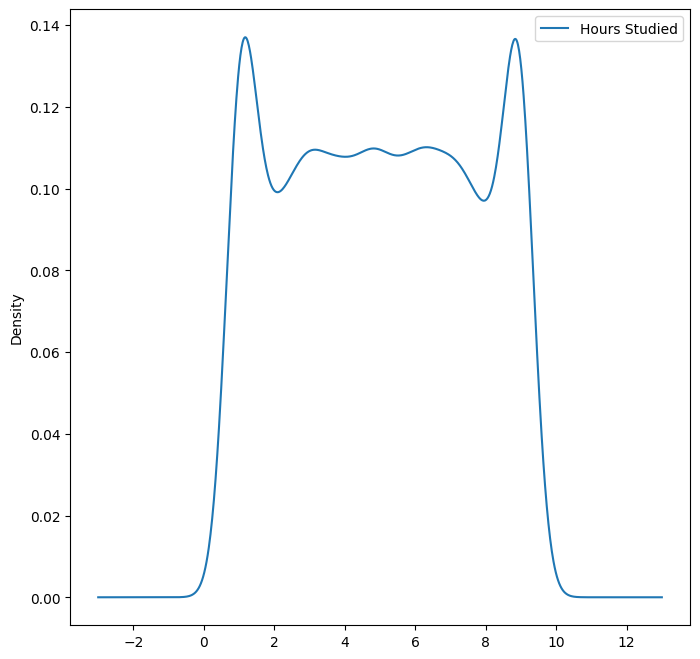

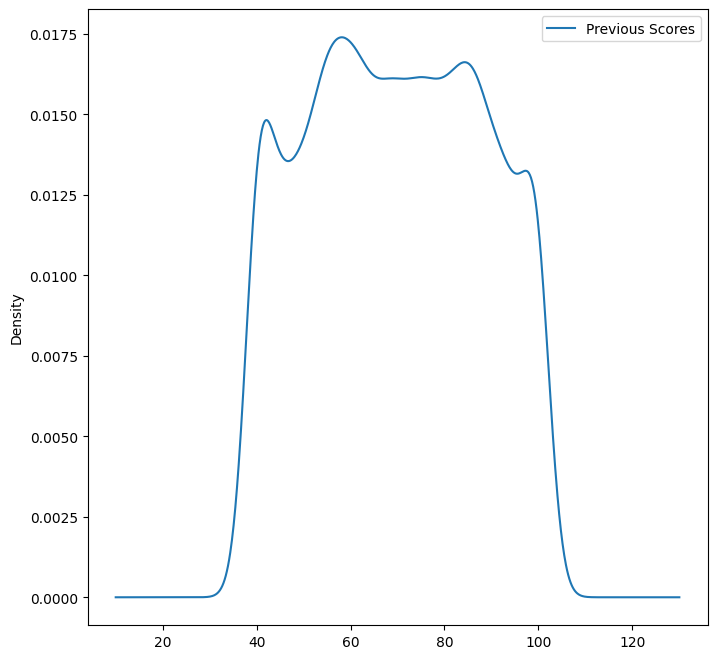

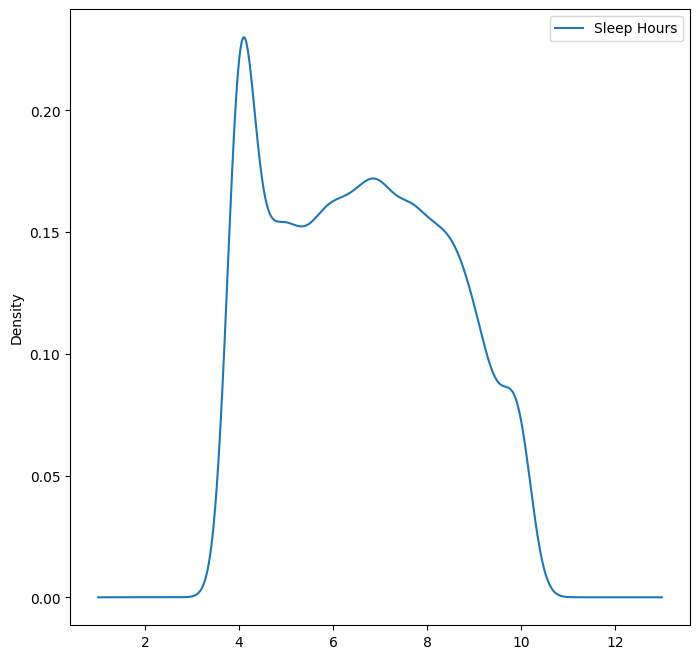

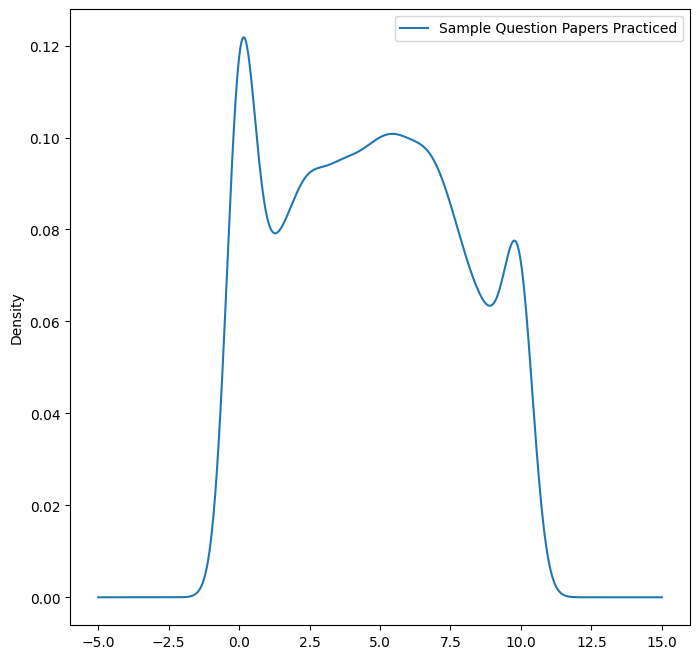

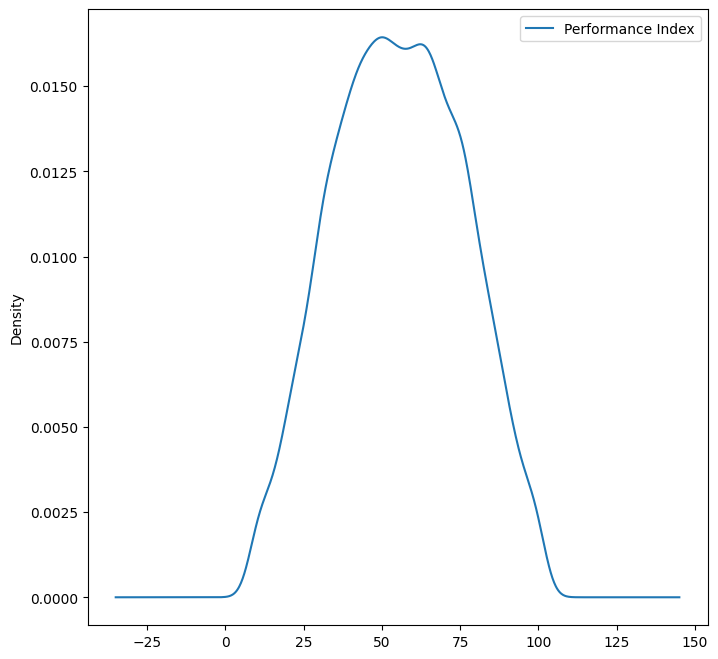

In [9]:
# custom function for printing all numeric columns plot
tdf =df.drop(['Extracurricular Activities'],axis=1)
def plotkde(a):
    tdf.plot(y=[a], kind='kde',figsize=(8,8))
allnc = tdf.columns
print(allnc)
for i in allnc:
    plotkde(i)

[[ 1.03054869  1.29792179  1.44684325 -1.65989173  1.51630463]
 [-0.38997679  0.57106642 -1.32953948 -1.65989173  0.86521281]
 [ 1.42644927 -1.31308769 -0.2206891  -1.25402972 -0.5552725 ]
 ...
 [ 0.04951518  0.91051396  0.55713177  0.56728269  1.0924997 ]
 [ 1.43599931  1.62197318 -0.78813089 -0.92035669  1.96476325]
 [ 1.10307958 -0.44315534  0.69385177 -0.88904941  1.00595757]]


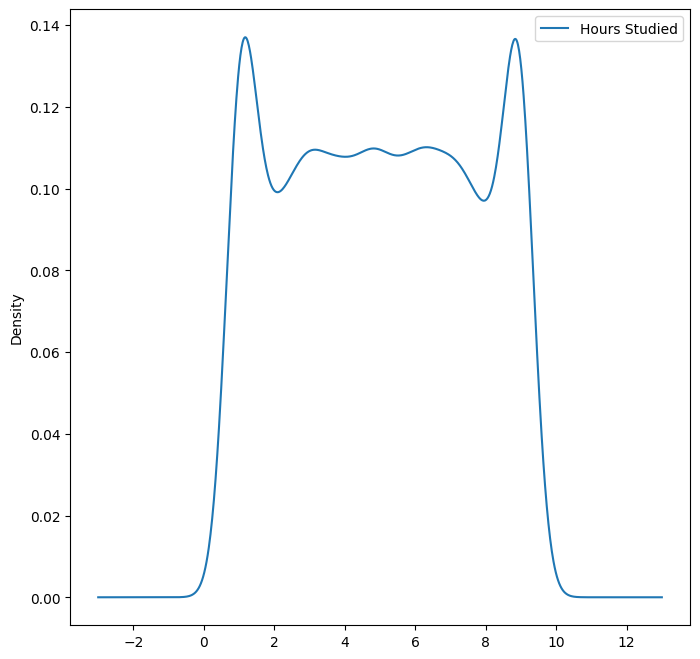

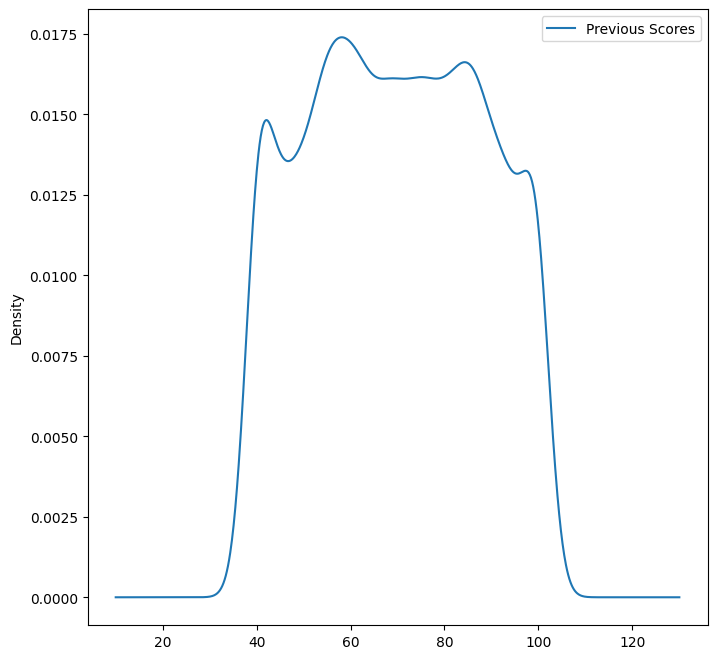

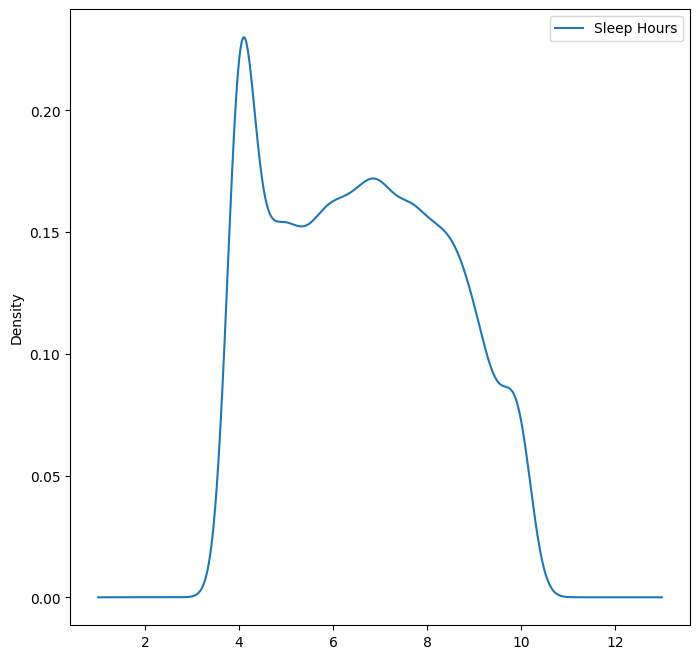

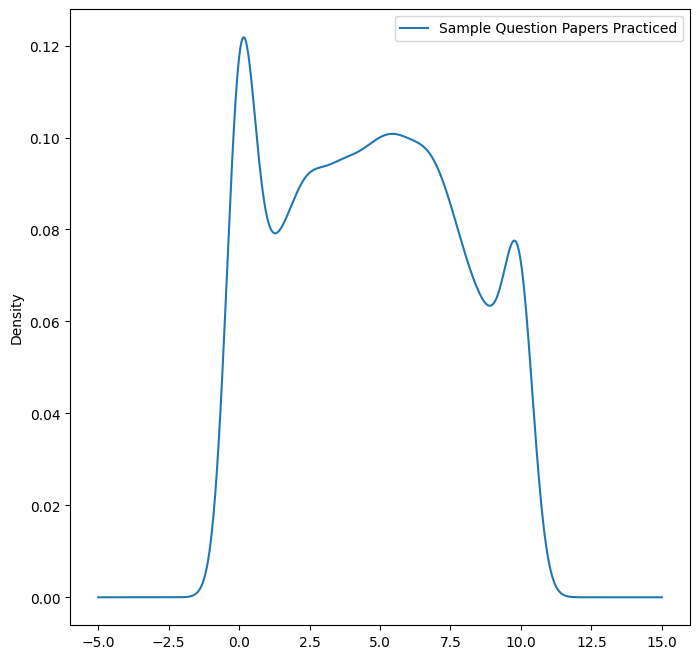

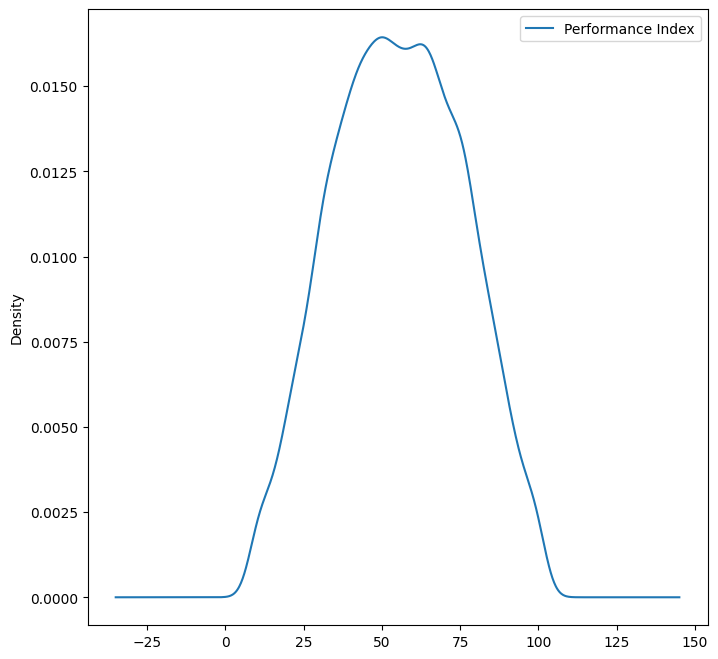

In [12]:
# after yeo-johnson
pt = PowerTransformer(method='yeo-johnson', standardize=True)
transformed = pt.fit_transform(tdf)
print(transformed)
transformed= pd.DataFrame(transformed, columns=['Hours Studied', 'Previous Scores', 'Sleep Hours',
                                                'Sample Question Papers Practiced', 'Performance Index'])
for i in transformed:
    plotkde(i)

In [13]:
# Yeo-Johnson completed ts work and now all the numerical columns are scaled and has their best possible lamda values
print('\n',pt.lambdas_)


 [0.70696995 0.73967691 0.39358495 0.65975962 0.88437626]


In [15]:
print(df.columns)

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')


In [19]:

X = df[['Hours Studied',
        'Previous Scores',
        'Extracurricular Activities',
        'Sleep Hours',
        'Sample Question Papers Practiced']]


y = df['Performance Index']


numeric_cols = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

categorical_cols = ['Extracurricular Activities']


preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         PowerTransformer(method='yeo-johnson', standardize=True),
         numeric_cols),

        ('cat',
         OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_cols)
    ]
)


pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])


In [20]:
scores = cross_val_score(pipe,X,y,cv=10,scoring='r2')

print("Fold Scores:", scores)
print("Mean R²:", scores.mean())
print("Std Dev:", scores.std())

Fold Scores: [0.71269555 0.68614868 0.69500983 0.67874169 0.70335982 0.67796323
 0.6919866  0.70634389 0.68238441 0.66908133]
Mean R²: 0.6903715026517168
Std Dev: 0.013305691217501392
